In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
dataset_path = r"C:\Users\monis\Downloads\archive (3)\ck\CK+48"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(48,48),
    batch_size=16,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(48,48),
    batch_size=16,
    color_mode="grayscale"
)

class_names = train_ds.class_names

print(class_names)

Found 981 files belonging to 7 classes.
Using 785 files for training.
Found 981 files belonging to 7 classes.
Using 196 files for validation.
['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']


In [3]:
model = keras.Sequential([

    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(7,activation='softmax')
])

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.2624 - loss: 1.8351 - val_accuracy: 0.2194 - val_loss: 1.8100
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3682 - loss: 1.6558 - val_accuracy: 0.4643 - val_loss: 1.2616
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6076 - loss: 1.0943 - val_accuracy: 0.6531 - val_loss: 0.9199
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7325 - loss: 0.7562 - val_accuracy: 0.7449 - val_loss: 0.6702
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7924 - loss: 0.5659 - val_accuracy: 0.7704 - val_loss: 0.5722
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7847 - loss: 0.5542 - val_accuracy: 0.8316 - val_loss: 0.3941
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8586 - loss: 0.3884 - val_accuracy: 0.8673 - val_loss: 0.3306
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8968 - loss: 0.2968 - val_accuracy: 0.8878 - v

In [6]:
print("Train Accuracy:",
      history.history['accuracy'][-1])

print("Validation Accuracy:",
      history.history['val_accuracy'][-1])

Train Accuracy: 0.9108280539512634
Validation Accuracy: 0.8979591727256775


In [7]:
model.save("emotion_model_final.h5")

print("Model Saved")

Model Saved


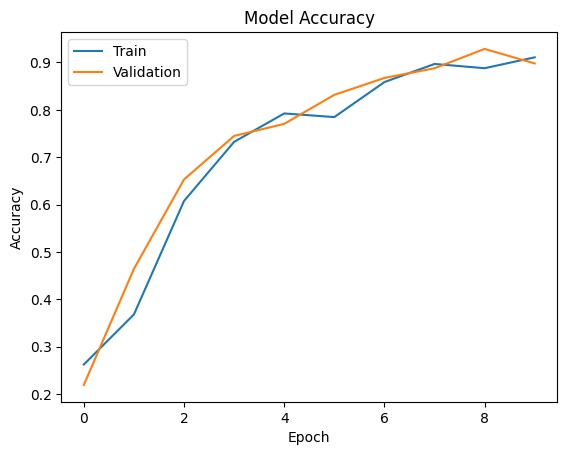

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

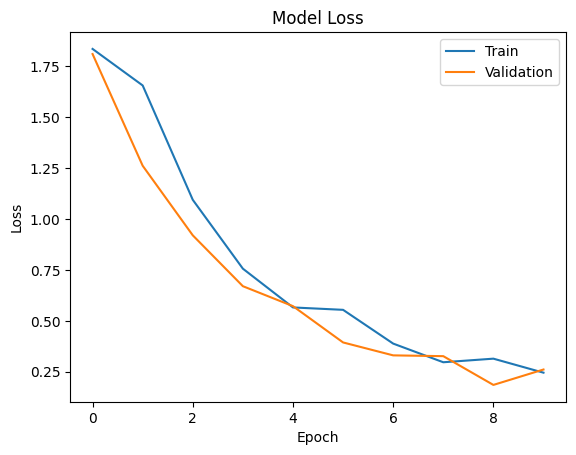

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [39]:
img = cv2.imread(
    r"C:\Users\monis\Downloads\archive (3)\CK+48\anger\S050_004_00000021.png",
    cv2.IMREAD_GRAYSCALE
)

img = cv2.resize(img,(48,48))

img = img.astype("float32")

img = np.expand_dims(img,-1)
img = np.expand_dims(img,0)

pred = model.predict(img,verbose=0)

print(
    "Prediction:",
    class_names[np.argmax(pred)]
)

Prediction: anger


In [38]:
img = cv2.imread(
    r"C:\Users\monis\Downloads\archive (3)\CK+48\surprise\S092_001_00000017.png",
    cv2.IMREAD_GRAYSCALE
)

img = cv2.resize(img,(48,48))

img = img.astype("float32")

img = np.expand_dims(img,-1)
img = np.expand_dims(img,0)

pred = model.predict(img,verbose=0)

print(
    "Prediction:",
    class_names[np.argmax(pred)]
)

Prediction: surprise


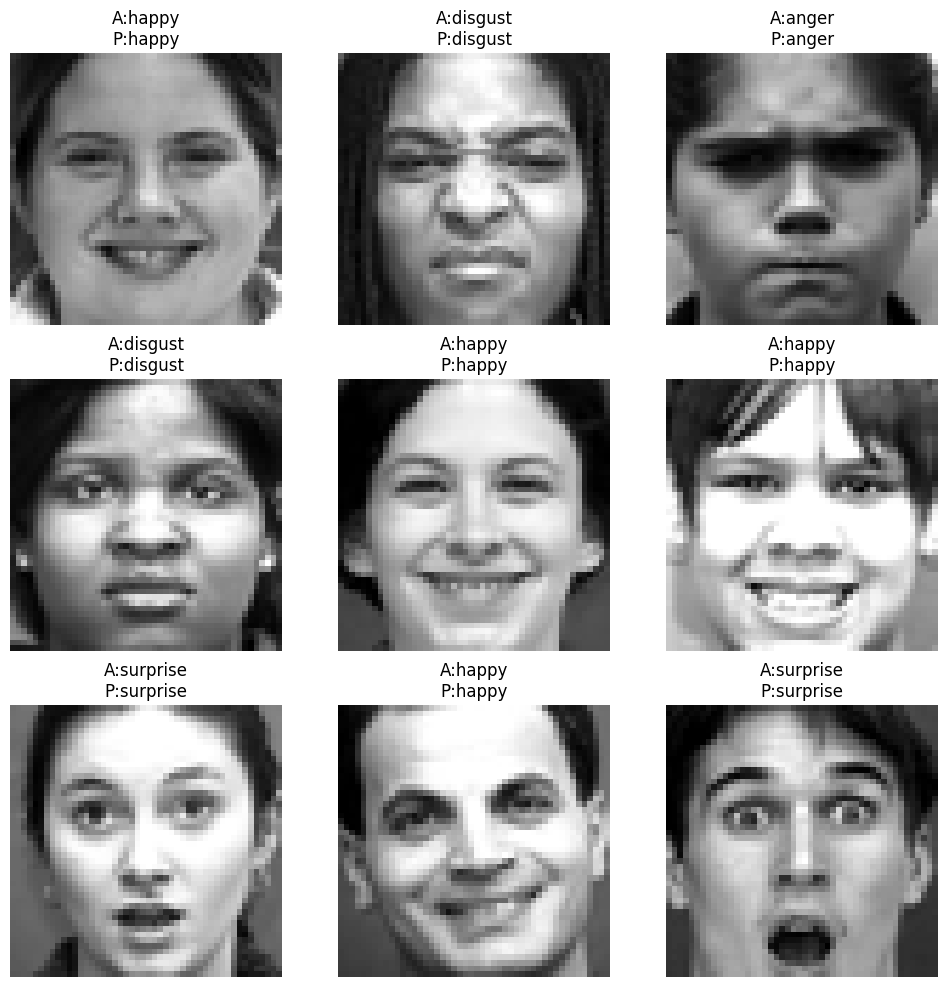

In [12]:
for images, labels in val_ds.take(1):

    pred = model.predict(images, verbose=0)

    plt.figure(figsize=(12,12))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap='gray')

        actual = class_names[labels[i]]
        predicted = class_names[np.argmax(pred[i])]

        plt.title(f"A:{actual}\nP:{predicted}")

        plt.axis("off")

    plt.show()

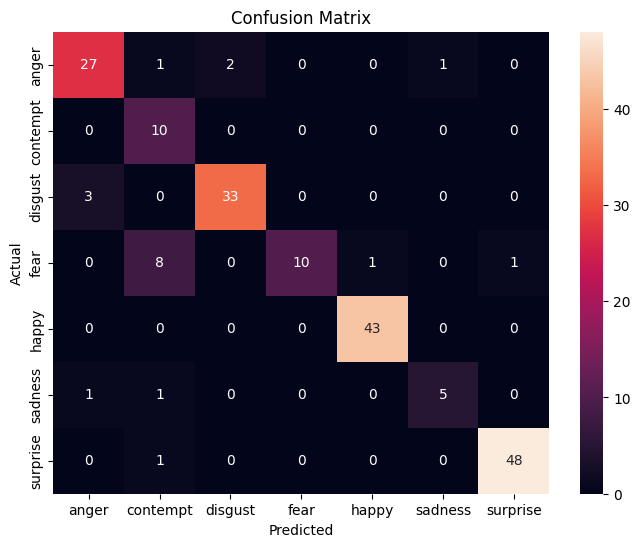

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [14]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       anger       0.87      0.87      0.87        31
    contempt       0.48      1.00      0.65        10
     disgust       0.94      0.92      0.93        36
        fear       1.00      0.50      0.67        20
       happy       0.98      1.00      0.99        43
     sadness       0.83      0.71      0.77         7
    surprise       0.98      0.98      0.98        49

    accuracy                           0.90       196
   macro avg       0.87      0.85      0.84       196
weighted avg       0.93      0.90      0.90       196



In [15]:
image_path = r"C:\Users\monis\Downloads\archive (3)\CK+48\surprise\S092_001_00000017.png"

img = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

img = cv2.resize(img,(48,48))

img = img.astype("float32")

img = np.expand_dims(img,-1)
img = np.expand_dims(img,0)

pred = model.predict(img,verbose=0)

emotion = class_names[np.argmax(pred)]

confidence = np.max(pred)*100

print("Emotion:", emotion)
print("Confidence:", confidence)

Emotion: surprise
Confidence: 100.0


In [16]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open webcam")
else:
    print("Webcam opened successfully")

    ret, frame = cap.read()

    if ret:
        print("Frame captured successfully")
        cv2.imwrite("webcam_test.jpg", frame)
        print("Saved as webcam_test.jpg")
    else:
        print("Failed to capture frame")

cap.release()

Webcam opened successfully
Frame captured successfully
Saved as webcam_test.jpg


In [19]:
import cv2
import time

cap = cv2.VideoCapture(0)

print("Get ready...")
time.sleep(3)

ret, frame = cap.read()

if ret:
    cv2.imwrite("my_emotion.jpg", frame)
    print("Image Captured!")
else:
    print("Capture Failed!")

cap.release()

Get ready...
Image Captured!


Predicted Emotion: happy
Confidence: 75.75 %
Predicted Emotion: happy
Confidence: 50.32 %


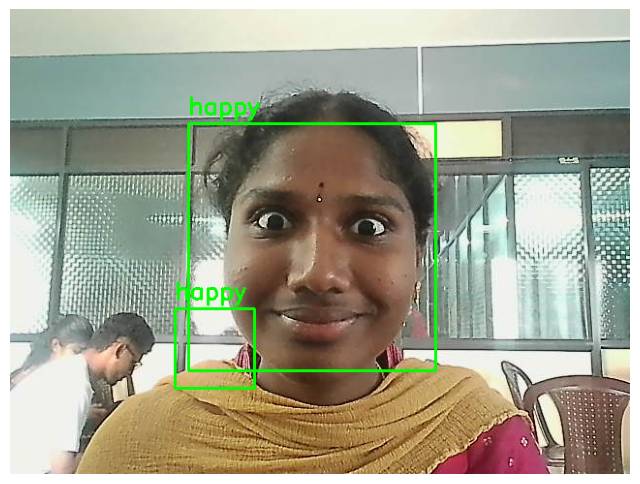

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    'anger',
    'contempt',
    'disgust',
    'fear',
    'happy',
    'sadness',
    'surprise'
]

image = cv2.imread("my_emotion.jpg")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)

for (x,y,w,h) in faces:

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(face,(48,48))

    face = face.astype("float32")

    face = np.expand_dims(face,-1)
    face = np.expand_dims(face,0)

    pred = model.predict(face,verbose=0)

    emotion = class_names[np.argmax(pred)]

    confidence = np.max(pred)*100

    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence,2), "%")

    cv2.rectangle(
        image,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

    cv2.putText(
        image,
        emotion,
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [28]:
import cv2
import time

cap = cv2.VideoCapture(0)

print("Get ready...")
time.sleep(3)

ret, frame = cap.read()

if ret:
    cv2.imwrite("my_emotion.jpg", frame)
    print("Image Captured!")
else:
    print("Capture Failed!")

cap.release()

Get ready...
Image Captured!


Predicted Emotion: disgust
Confidence: 87.22 %


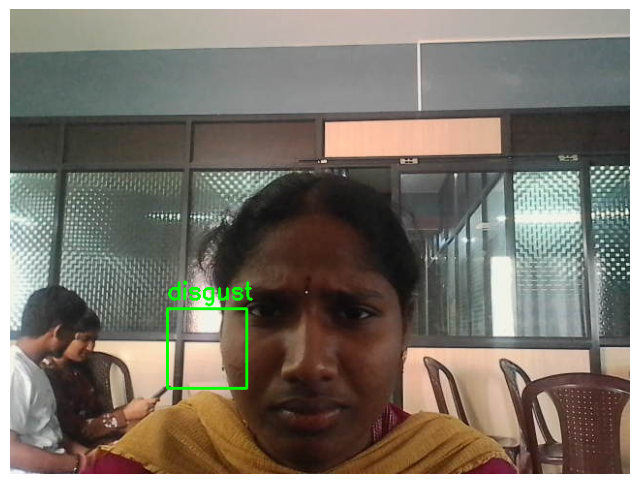

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    'anger',
    'contempt',
    'disgust',
    'fear',
    'happy',
    'sadness',
    'surprise'
]

image = cv2.imread("my_emotion.jpg")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)

for (x,y,w,h) in faces:

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(face,(48,48))

    face = face.astype("float32")

    face = np.expand_dims(face,-1)
    face = np.expand_dims(face,0)

    pred = model.predict(face,verbose=0)

    emotion = class_names[np.argmax(pred)]

    confidence = np.max(pred)*100

    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence,2), "%")

    cv2.rectangle(
        image,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

    cv2.putText(
        image,
        emotion,
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [36]:
import cv2
import time

cap = cv2.VideoCapture(0)

print("Get ready...")
time.sleep(3)

ret, frame = cap.read()

if ret:
    cv2.imwrite("my_emotion.jpg", frame)
    print("Image Captured!")
else:
    print("Capture Failed!")

cap.release()

Get ready...
Image Captured!


Predicted Emotion: disgust
Confidence: 30.49 %


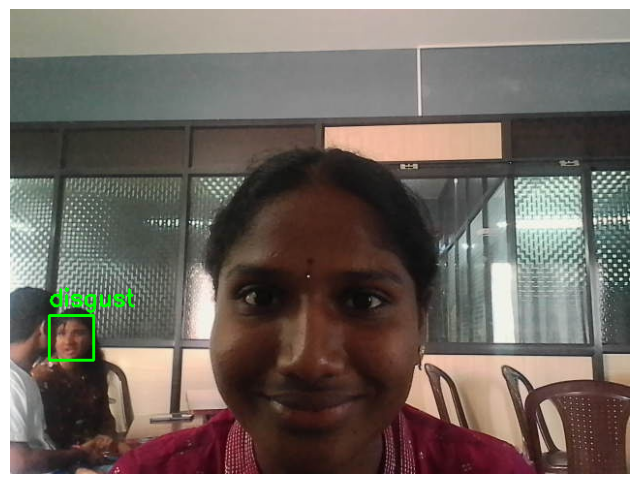

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    'anger',
    'contempt',
    'disgust',
    'fear',
    'happy',
    'sadness',
    'surprise'
]

image = cv2.imread("my_emotion.jpg")

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)

for (x,y,w,h) in faces:

    face = gray[y:y+h, x:x+w]

    face = cv2.resize(face,(48,48))

    face = face.astype("float32")

    face = np.expand_dims(face,-1)
    face = np.expand_dims(face,0)

    pred = model.predict(face,verbose=0)

    emotion = class_names[np.argmax(pred)]

    confidence = np.max(pred)*100

    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence,2), "%")

    cv2.rectangle(
        image,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

    cv2.putText(
        image,
        emotion,
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,0),
        2
    )

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()